# Solve 1D Wave equation: 
\begin{equation}
\begin{cases} 
    u_{tt}(x,t) - 4u_{xx}(x,t) = 0 \quad x \in [0, 1], \ t \in [0, 1] \\ 
    u(0,t) = u(1,t) = 0 \\ 
    u_{t}(x,0) = 0 \\ 
    u(x,0) = \sin(\pi x) + \frac{1}{2} \sin(4\pi x) 
\end{cases}
\end{equation} 
$$
u(x,t) = \sin(\pi x) \cos(2\pi t) + \frac{1}{2} \sin(4\pi x) \cos(8\pi t)  
$$

In [1]:
import torch 
from torch import nn 
from collections import OrderedDict # To place the hidden layers orderly 

import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from utils.data import * 
from utils.SA_PINN_structure import * 
from Wave_utils import * 
import warnings

warnings.filterwarnings('ignore') # Import the built-in Python warnings module, and tell Python to ignore all warning messages.”
import time 

In [2]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available():
    device = torch.device('cuda') 
else:
    device = torch.device('cpu') 
# 
print(f"Working on {device}") 

Working on mps


# Self-Adaptive Physics-informed Neural Network 

In [17]:
class AdaptiveLoss(nn.Module): 
    def __init__(self, layers, N_r, N_b, N_0): 
        super(AdaptiveLoss, self).__init__()

        # Layers 
        self.depth = len(layers) - 1 # total layers, including the input and out put layers 

        # Self Adaptive parameters 
        # The parameters will be included in adaptive_loss.parameters() 
        self.lambda_r = nn.Parameter(torch.rand(N_r, 1), requires_grad = True) 
        self.lambda_b = nn.Parameter(torch.rand(N_b, 1), requires_grad = True) 
        self.lambda_0 = nn.Parameter(torch.rand(N_0, 1), requires_grad = True) 
        

        # Set up layer order dict 
        self.activation = nn.Tanh() 

        layer_list = list() 
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, nn.Linear(layers[i], layers[i+1])) 
            ) 
            layer_list.append(('activation_%d' % i, self.activation)) 

        layer_list.append( 
            ('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1])) 
        ) 
        layerDict = OrderedDict(layer_list) 

        # deploy layers 
        self.layers = nn.Sequential(layerDict) 

    def forward(self, x): 
        out = self.layers(x) 
        return out 

In [6]:
class SA_PINN_Wave(nn.Module): 
    def __init__(self, X_train, X_init, U_init, t_bc, layers, lb, ub, N_r = 5000, N_b = 200, N_0 = 100):  
        super().__init__() 
        # boundary conditions: domain bounds 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device) 

        # Initial setup    
        self.N_r = N_r
        self.N_b = N_b
        self.N_0 = N_0 

        # Interior Points 
        self.x = torch.tensor(X_train[:, 0:1], requires_grad = True).float().to(device) # spatial points 
        self.t = torch.tensor(X_train[:, 1:2], requires_grad = True).float().to(device) # temporal points  

        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # initial data points 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # t = 0 
        self.t_init.requires_grad_(True) 
        self.u_init = torch.tensor(U_init).float().to(device)

        # Boundary data points for periodic boundary conditions 
        self.t_bc = torch.tensor(t_bc).float().to(device) 
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc) 
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc)  
        self.N_bc = self.t_bc.shape[0]

        
        # deep neural network 
        self.dnn = AdaptiveLoss(layers, N_r, N_b, N_0).to(device) 

        
        # optimizers: using the same settings 
        self.optimizer = torch.optim.LBFGS( # requires multiple evaluation of the loss function per iteration 
            self.dnn.layers.parameters(),    # target to be optimized 
            lr = 1.0,    # learning rate: step length 
            max_iter = 1,    # maximum number of iterations 
            max_eval = 500000,    # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9, 
            line_search_fn = "strong_wolfe"      # "strong wolfe condition
        ) 
        
        self.optimizer_Adam = torch.optim.Adam(self.dnn.layers.parameters(), lr = 2e-4, betas = (0.9, 0.999))
        self.optimizer_Adam_r = torch.optim.Adam([self.dnn.lambda_r], lr = 5e-4, betas = (0.9, 0.999)) # Optimizers always take lists / iterables, never single tensors directly
        self.optimizer_Adam_b = torch.optim.Adam([self.dnn.lambda_b], lr = 5e-4, betas = (0.9, 0.999)) 
        self.optimizer_Adam_0 = torch.optim.Adam([self.dnn.lambda_0], lr = 5e-4, betas = (0.9, 0.999)) 
        # Record the iteration number 
        self.iter = 0 
    
    
    def net_u(self, x, t): # predicted value 
        u = self.dnn(torch.cat([x, t], dim = 1))
        return u

    def PDE_residual(self, x, t): 
        u = self.net_u(x, t) 

        u_x = torch.autograd.grad(
            outputs = u, 
            inputs = x, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True
        )[0] 

        u_xx = torch.autograd.grad(
            outputs = u_x, 
            inputs = x, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0] 

        u_t = torch.autograd.grad(
            outputs = u, 
            inputs = t, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True 
        )[0] 

        u_tt = torch.autograd.grad(
            outputs = u_t, 
            inputs = t, 
            grad_outputs = torch.ones_like(u_t), 
            create_graph = True 
        )[0] 
            
        # PDE residual loss 
        f = u_tt - 4 * u_xx 
        return f
    
    def loss_func(self, x_init, t_init, u_init, x_int, t_int, x_left, x_right, t_bc, lambda_0, lambda_r, lambda_b):  
        f_pred = self.PDE_residual(x_int, t_int) 
        u0_pred = self.net_u(x_init, t_init) 
        u0_t_pred = torch.autograd.grad(
            outputs = u0_pred, 
            inputs = t_init,
            grad_outputs = torch.ones_like(u0_pred), 
            create_graph = True
        )[0] 
        u_left_pred = self.net_u(x_left, t_bc) 
        u_right_pred = self.net_u(x_right, t_bc) 
        
        mse_r_u = torch.pow(f_pred, 2) 
        mse_0_u = torch.pow(u0_pred - u_init, 2) 
        mse_0_u_t = torch.pow(u0_t_pred, 2) 
        mse_b_u_left = torch.pow(u_left_pred, 2) 
        mse_b_u_right = torch.pow(u_right_pred, 2) 
         
        lb_detach = lambda_b.detach()
        l0_detach = lambda_0.detach() 
        mse_b = torch.mean(torch.pow(lb_detach[:self.N_bc], 2) * mse_b_u_left) + torch.mean(torch.pow(lb_detach[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right) 
        mse_b_detach = torch.mean(torch.pow(lambda_b[:self.N_bc], 2) * mse_b_u_left.detach()) + torch.mean(torch.pow(lambda_b[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right.detach()) 

        mse_0 = torch.mean(torch.pow(l0_detach, 2) * (mse_0_u + mse_0_u_t))
        mse_0_detach = torch.mean(torch.pow(lambda_0, 2) * (mse_0_u.detach() + mse_0_u_t.detach())) 
        
        return (
            
            mse_0 + mse_b + torch.mean(torch.pow(lambda_r.detach(), 2) * mse_r_u),
            mse_0_detach, 
            mse_b_detach, 
            torch.mean(torch.pow(lambda_r, 2) * mse_r_u.detach()),
        )
   
    # For the optimization of LBFGS 
    def closure(self):
        loss_value, mse_0, mse_b, mse_r = self.loss_func(self.x_init, self.t_init, self.u_init, self.x, self.t, self.x_left, self.x_right, self.t_bc, self.dnn.lambda_0, 
                                                         self.dnn.lambda_r, self.dnn.lambda_b) 
        self.optimizer.zero_grad()                             # reset gradients
        loss_value.backward()                                  # compute gradients but only the network weights will be updated 
        return loss_value  
    
    def Optimize(self, Iter1, Iter2): 
        self.dnn.train()
        # Backward and optimize: 2nd phase optimization 
        # Two Phase optimization
        
        for epoch in range(Iter1):
            
            loss_value, mse_0, mse_b, mse_r = self.loss_func(self.x_init, self.t_init, self.u_init, self.x, self.t, self.x_left, self.x_right, self.t_bc, self.dnn.lambda_0, 
                                                      self.dnn.lambda_r, self.dnn.lambda_b)  

            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss_value.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 

            self.optimizer_Adam_0.zero_grad() 
            self.optimizer_Adam_r.zero_grad() 
            self.optimizer_Adam_b.zero_grad() 

            (- mse_0).backward() 
            (- mse_b).backward() 
            (- mse_r).backward()

            self.optimizer_Adam_0.step() # only sees the gradient of lambda_0 
            self.optimizer_Adam_b.step() # only sees the gradient of lambda_b  
            self.optimizer_Adam_r.step() # only sees the gradient of lambda_r 
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss_value.item()
                    )
                )

        for i in range(Iter2):  
            self.optimizer.step(self.closure) # Never pass tensors into optimizer.step()
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))

    def predict(self, X):
        x = torch.as_tensor(X[:, 0:1], dtype = torch.float32, device = device) 
        x.requires_grad_(True) 
        t = torch.as_tensor(X[:, 1:2], dtype = torch.float32, device = device) 
        t.requires_grad_(True)  

        self.dnn.eval()
        with torch.no_grad():
            u = self.net_u(x, t) 
        f = self.PDE_residual(x, t) 
        
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        
        return u, f     

# Configurations 

In [7]:
# Domain bounds 
lb = np.array([0.0, 0.0]) # second element for time 
ub = np.array([1.0, 1.0]) # second element for time                                                

# Grid point setup 
N_bc = 100
Nx_int = 50
Nt_int = 100 
N_init = 100  

# Training points
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_init = init_points(N_init, lb[0], ub[0]) 
U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc)) 

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [8]:
Nx = 200; Nt = 50 
X_test, u_test = test_data(Nx, Nt, lb[0], ub[0], lb[1], ub[1])

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy data

In [9]:
noise = 0.0 
N_r = 5000 
N_b = 200 
N_0 = 100 
layers = [2] + [30] * 12 + [1] 
model = SA_PINN_Wave(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub, N_r, N_b, N_0) 
# training
start = time.time()
model.Optimize(10000, 500)
end = time.time()

It: 0, Loss: 2.560e-01
It: 100, Loss: 2.136e-01
It: 200, Loss: 2.235e-01
It: 300, Loss: 2.368e-01
It: 400, Loss: 2.584e-01
It: 500, Loss: 3.077e-01
It: 600, Loss: 3.342e-01
It: 700, Loss: 3.646e-01
It: 800, Loss: 4.114e-01
It: 900, Loss: 4.655e-01
It: 1000, Loss: 5.119e-01
It: 1100, Loss: 5.795e-01
It: 1200, Loss: 6.325e-01
It: 1300, Loss: 7.205e-01
It: 1400, Loss: 7.698e-01
It: 1500, Loss: 8.316e-01
It: 1600, Loss: 1.124e+00
It: 1700, Loss: 9.890e-01
It: 1800, Loss: 1.056e+00
It: 1900, Loss: 1.378e+00
It: 2000, Loss: 1.188e+00
It: 2100, Loss: 1.190e+00
It: 2200, Loss: 1.172e+00
It: 2300, Loss: 1.236e+00
It: 2400, Loss: 1.326e+00
It: 2500, Loss: 1.434e+00
It: 2600, Loss: 1.464e+00
It: 2700, Loss: 1.567e+00
It: 2800, Loss: 1.623e+00
It: 2900, Loss: 1.791e+00
It: 3000, Loss: 1.866e+00
It: 3100, Loss: 1.940e+00
It: 3200, Loss: 2.062e+00
It: 3300, Loss: 2.087e+00
It: 3400, Loss: 2.173e+00
It: 3500, Loss: 2.282e+00
It: 3600, Loss: 2.550e+00
It: 3700, Loss: 2.478e+00
It: 3800, Loss: 3.043e+0

In [10]:
# evaluations 
u_pred, f_pred = model.predict(X_test) 
print(f"u_pred shape: {np.shape(u_pred)}") 
print(f"f_pred shape: {np.shape(f_pred)}") 


error_u = np.linalg.norm(u_test - u_pred, 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
error_f = np.linalg.norm(f_pred, ord = np.inf) 

print('Error u: %e' % (error_u)) 
print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end-start:.2f} seconds')

u_pred shape: (10000, 1)
f_pred shape: (10000, 1)
Error u: 4.986512e-01
PDE loss: 1.178253e+00
Training time is 474.41 seconds


# Collecting Error Data 

In [55]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
N_r = 5000 
N_b = 200
N_0 = 100 
 
layers = [2] + [30] * 12 + [1] 

training_sets = np.load(
    "Wave_Equation_training_points_sets.npy",
    allow_pickle=True
)


for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"]
    model = SA_PINN_Wave(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub, N_r, N_b, N_0) 
    start = time.time() 
    model.Optimize(10000, 500) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 2.074e-01
It: 100, Loss: 1.689e-01
It: 200, Loss: 1.739e-01
It: 300, Loss: 1.934e-01
It: 400, Loss: 2.178e-01
It: 500, Loss: 2.478e-01
It: 600, Loss: 2.823e-01
It: 700, Loss: 3.179e-01
It: 800, Loss: 3.588e-01
It: 900, Loss: 4.019e-01
It: 1000, Loss: 4.499e-01
It: 1100, Loss: 5.028e-01
It: 1200, Loss: 5.549e-01
It: 1300, Loss: 6.148e-01
It: 1400, Loss: 6.733e-01
It: 1500, Loss: 7.406e-01
It: 1600, Loss: 8.048e-01
It: 1700, Loss: 8.808e-01
It: 1800, Loss: 9.499e-01
It: 1900, Loss: 1.023e+00
It: 2000, Loss: 1.111e+00
It: 2100, Loss: 1.187e+00
It: 2200, Loss: 1.618e+00
It: 2300, Loss: 1.363e+00
It: 2400, Loss: 1.448e+00
It: 2500, Loss: 1.536e+00
It: 2600, Loss: 1.652e+00
It: 2700, Loss: 1.738e+00
It: 2800, Loss: 1.831e+00
It: 2900, Loss: 1.945e+00
It: 3000, Loss: 2.041e+00
It: 3100, Loss: 2.142e+00
It: 3200, Loss: 2.272e+00
It: 3300, Loss: 2.363e+00
It: 3400, Loss: 2.465e+00
It: 3500, Loss: 2.619e+00
It: 3600, Loss: 2.726e+00
It: 3700, Loss: 2.841e+00
It: 3800, Loss: 3.046e+0

In [56]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

err_l2 mean:  0.6227239900111844
[0.96821248 0.60713092 0.71608467 0.45878209 0.47305863 0.49817456
 0.61072018 0.46928945 0.97194374 0.45384318]
0.19164349529274172
err_linf mean:  0.9498246640098562
0.32297479226840986
Training_time mean:  480.34480061531065
24.09872203329075


In [ ]:
# Save the results 
results = {
    "Model": "SA_PINN",
    "num_features": layers, 
    "Training_points_int_bc": [Nx_int, Nt_int, N_init, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Wave_PINN_5000_training_points_data.pt")

# Visualization 

' \nfig.subplots_adjust(\n    wspace=0.08,\n    bottom=0.25\n)\n'

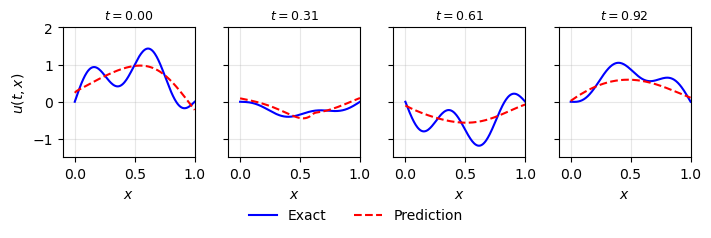

In [11]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={X_test[idx * Nx, 1]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-0.1,1.0])
    ax.set_ylim([-1.5,2.0])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')
""" 
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.75),
    ncol=2,
    frameon=False
)
"""
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)
""" 
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)
""" 
# fig.savefig("Wave_SA_PINN.png", dpi=300, bbox_inches='tight')